# NB12b LSTM-AE - Kaggle-tunde, NB12 recipe + per-window Z-Norm

Sibling to NB 12. Same architecture, same FIT_SIZE, same last-50k slice, same callbacks as NB 12.

**Two deliberate differences** (both target Kaggle-tail extrapolation failure):

1. **Threshold tuning on `corrected_event_f05`** (ESA metric) — Kaggle's own objective.
2. **Per-window Z-Norm** (`ZNormAdapter`) — *drift-robustness at the input layer*. Every 100-row window is mean-centred and variance-normalised per channel **before** the LSTM sees it. The AE learns to reconstruct z-space patterns (shapes, transients), not raw magnitudes. Under drift, Kaggle windows look like training windows after z-norming, because the slow level-shift is removed per window.
   - Revives NB 12's "Option A" (which was tested and replaced by Option B for test_intern, but Option B was known to be drift-fragile on Kaggle).
   - Trade-off: sustained single-level anomaly offsets (all channels +5 for 100 rows) are normalised away. Only within-window-shape anomalies survive. Empirically these are most ESA events in this dataset.

**Key settings**:
- Architecture: Bi-LSTM(128) → LSTM(64) → LSTM(8) latent → RepeatVector → LSTM(64) → LSTM(128) → TimeDistributed(58)  (≈ 401 k params)
- Fit: last 50 000 nominal windows pre-`TRAIN_END`, **z-normed per window**
- Scoring: `ZNormAdapter(model)` wraps the model, MSE is computed in z-space via `topk=5`
- Threshold: candidate sweep (val-ESA, val-nominal-percentile, test_internal-percentile, kaggle-percentile) with 20 %-flag-rate safety cap

**Outputs**: `models/lstm_ae_kaggle_<timestamp>.keras` (trained on z-normed inputs), `kaggle/submissions/nb12b_lstm_ae_kaggle_<variant>.parquet`.

## 0 — Setup

In [1]:
import sys, time, os
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05
from sentinel.ml_logic.data       import find_anomaly_segments
from kaggle.submission            import make_submission, default_submission_path, submission_summary

tf.keras.utils.set_random_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

KAGGLE_DIR   = PROCESSED_DIR / 'kaggle'
KAGGLE_LEN   = 521_280
FIT_SIZE_EXP = 50_000          # matches NB 12 (was 20_000; 20k collapsed scores)
TOPK         = 5               # matches NB 12

print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'KAGGLE_DIR   : {KAGGLE_DIR}')
print(f'FIT_SIZE_EXP : {FIT_SIZE_EXP:,} (last nominal windows of train portion)')
print(f'WINDOW_SIZE  : {WINDOW_SIZE}')
print(f'TOPK         : {TOPK}')

TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
KAGGLE_DIR   : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
FIT_SIZE_EXP : 50,000 (last nominal windows of train portion)
WINDOW_SIZE  : 100
TOPK         : 5


## 1 — Load Kaggle arrays

Kaggle preprocessing keeps the **entire** `train.parquet` as training material. `X_train_full` contains every non-overlapping window (nominal + anomalous); `y_train_full` is the per-window label. We filter to nominal and take the tail.

In [2]:
X_train_full = np.load(KAGGLE_DIR / 'X_train_full.npy')
y_train_full = np.load(KAGGLE_DIR / 'y_train_full.npy')
y_train_row  = np.load(KAGGLE_DIR / 'y_train_row.npy')
train_scaled = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
test_scaled  = np.load(KAGGLE_DIR / 'test_scaled.npy')
test_ids     = np.load(KAGGLE_DIR / 'test_ids.npy')

N_FEAT = X_train_full.shape[-1]

print(f'X_train_full  : {X_train_full.shape}  dtype={X_train_full.dtype}')
print(f'y_train_full  : {y_train_full.shape}  nominal={int((y_train_full==0).sum()):,}  '
      f'anom={int((y_train_full==1).sum()):,}')
print(f'train_scaled  : {train_scaled.shape}  (row-level, mmap)')
print(f'test_scaled   : {test_scaled.shape}')
print(f'test_ids      : {test_ids.shape}  range [{test_ids.min()}, {test_ids.max()}]')
print(f'N_FEAT        : {N_FEAT}')

X_train_full  : (147283, 100, 58)  dtype=float32
y_train_full  : (147283,)  nominal=131,645  anom=15,638
train_scaled  : (14728321, 58)  (row-level, mmap)
test_scaled   : (521280, 58)
test_ids      : (521280,)  range [14728321, 15249600]
N_FEAT        : 58


## 1b — Boundary check: keep splits out of anomaly events

Target split: `train = [:10_700_000]`, `val = [10_700_000:12_700_000]`, `test_internal = [12_700_000:]`.

If either target row is itself anomalous — or sits inside a ±few-k-row anomaly cluster — slicing there would cut a real event in half and both sides would see partial anomalies. Metrics on val/test would then be biased.

Rule: shift each boundary to the nearest row where `y_train_row == 0` **and** the ±`MIN_CLEAR` neighbourhood is fully nominal.

In [3]:
from scipy.ndimage import uniform_filter1d

TRAIN_END_TARGET = 10_700_000
VAL_END_TARGET   = 12_700_000
MIN_CLEAR        = 2_000
SEARCH_RADIUS    = 100_000

def find_clean_boundary(y_row, target, min_clear=MIN_CLEAR, radius=SEARCH_RADIUS):
    n = len(y_row)
    lo = max(0, target - radius)
    hi = min(n, target + radius)
    window = y_row[lo:hi].astype(np.int32)
    k = 2 * min_clear + 1
    local_sum = uniform_filter1d(window, size=k, mode='nearest') * k
    clean = (local_sum == 0)
    if not clean.any():
        raise ValueError(f'No clean ±{min_clear:,}-row gap within ±{radius:,} of {target:,}')
    clean_abs = np.where(clean)[0] + lo
    return int(clean_abs[np.abs(clean_abs - target).argmin()])

def boundary_report(y_row, pos, ctx=3_000):
    lo, hi = max(0, pos - ctx), min(len(y_row), pos + ctx)
    return {
        'pos'             : pos,
        'y[pos]'          : int(y_row[pos]),
        f'anom_in_±{ctx}' : int(y_row[lo:hi].sum()),
    }

print('--- Target boundaries ---')
print(f'train_end : {boundary_report(y_train_row, TRAIN_END_TARGET)}')
print(f'val_end   : {boundary_report(y_train_row, VAL_END_TARGET)}')

TRAIN_END = find_clean_boundary(y_train_row, TRAIN_END_TARGET)
VAL_END   = find_clean_boundary(y_train_row, VAL_END_TARGET)

print('\n--- Adjusted boundaries (clean ±{:,}-row neighbourhood) ---'.format(MIN_CLEAR))
print(f'TRAIN_END : {TRAIN_END:>10,}  (shift {TRAIN_END - TRAIN_END_TARGET:+,})')
print(f'VAL_END   : {VAL_END:>10,}  (shift {VAL_END   - VAL_END_TARGET:+,})')

n_full   = len(train_scaled)
train_n  = TRAIN_END
val_n    = VAL_END - TRAIN_END
test_n   = n_full - VAL_END
print(f'\nBlock sizes   : train={train_n:,}  val={val_n:,}  test_internal={test_n:,}  total={n_full:,}')
print(f'Anom in train : {int(y_train_row[:TRAIN_END].sum()):,}')
print(f'Anom in val   : {int(y_train_row[TRAIN_END:VAL_END].sum()):,}')
print(f'Anom in test  : {int(y_train_row[VAL_END:].sum()):,}')

--- Target boundaries ---
train_end : {'pos': 10700000, 'y[pos]': 0, 'anom_in_±3000': 0}
val_end   : {'pos': 12700000, 'y[pos]': 0, 'anom_in_±3000': 0}

--- Adjusted boundaries (clean ±2,000-row neighbourhood) ---
TRAIN_END : 10,700,000  (shift +0)
VAL_END   : 12,700,000  (shift +0)

Block sizes   : train=10,700,000  val=2,000,000  test_internal=2,028,321  total=14,728,321
Anom in train : 1,113,371
Anom in val   : 215,798
Anom in test  : 214,935


## 2 — Build LSTM-AE (NB 12 architecture, ≈ 401 k params)

Exact copy of NB 12's architecture:

In [4]:
LATENT_DIM = 8
HIDDEN_DIM = 128
DROPOUT    = 0.1

def build_lstm_ae(window_size, n_channels,
                  latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
    inputs = layers.Input(shape=(window_size, n_channels))

    # Encoder
    x = layers.Bidirectional(
            layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)
        )(inputs)                                                         # (100, 2*hidden_dim)
    x = layers.LSTM(hidden_dim // 2, return_sequences=True,  dropout=dropout)(x)
    latent = layers.LSTM(latent_dim, return_sequences=False, dropout=dropout)(x)

    # Bottleneck
    x = layers.RepeatVector(window_size)(latent)

    # Decoder
    x = layers.LSTM(hidden_dim // 2, return_sequences=True, dropout=dropout)(x)
    x = layers.LSTM(hidden_dim,      return_sequences=True, dropout=dropout)(x)

    outputs = layers.TimeDistributed(layers.Dense(n_channels))(x)

    model = Model(inputs, outputs, name='lstm_ae')
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_ae(WINDOW_SIZE, N_FEAT)
model.summary()

Model: "lstm_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 58)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       191,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 64)        │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8)              │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 64)        │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 58)        │         7,482 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 400,986 (1.53 MB)

 Trainable params: 400,986 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

### Z-Norm wrapper

Per-window, per-channel standardisation. `ZNormAdapter.predict(X)` feeds the **z-normed** input to the underlying model, but returns `X - Xn + Xhat_n` — an algebraic trick that makes `score_windows` compute MSE **in z-space** (between `Xn` and the z-space reconstruction) without touching `score_windows`'s implementation:

```
(X − adapter_output)² = (X − (X − Xn + Xhat_n))² = (Xn − Xhat_n)²
```

Result: scoring is drift-invariant per window.

In [5]:
def zscore_window(X):
    """Per-window, per-channel standardisation. X: (B, 100, 58) -> same shape."""
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)

class ZNormAdapter:
    """
    Transparent wrapper for score_windows. Applies per-window z-norm before
    inference and returns X - Xn + Xhat_n so that score_windows' MSE between
    X and this output equals MSE between Xn and Xhat_n (z-space MSE).
    """
    def __init__(self, model):
        self.model = model
    def predict(self, X, batch_size=256, verbose=0):
        Xn     = zscore_window(X)
        Xhat_n = self.model.predict(Xn, batch_size=batch_size, verbose=verbose)
        return X - Xn + Xhat_n

scorer = ZNormAdapter(model)
print('ZNormAdapter wired. Fit + scoring will use z-normed windows.')

ZNormAdapter wired. Fit + scoring will use z-normed windows.


## 3 — Fit on last 50 000 nominal windows **of the train portion**

Mirrors NB 12 exactly:

- **Pool**: nominal windows with their starting row `< TRAIN_END` (i.e. only the train portion — val/test_internal stay disjoint).
- **Slice**: the **last 50 000** of that pool. NB 12 did `X_train_nom[-50000:]` against a 70/15/15-split `X_train_nom`; here `X_train_full` spans the whole `train.parquet`, so we first restrict to the train portion, then take the tail.
- Recency-bias is intentional: the closer the fit pool is to the val/test regime, the smaller the nominal-drift gap the AE has to cross. NB 12 showed a drop from Event F0.5 ≈ 0.98 → 0.09 when fit on *all* nominal windows instead of the last 50k.

Callbacks identical to NB 12 (not the NB 11b/12b-v1 tweaks):
- `EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)`
- `ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-5)`

In NB 12 this converged at epoch 1 (val_loss rose from epoch 2 onwards) and restored best weights — the 1-epoch state was actually where the anomaly/nominal separation was largest.

In [6]:
nominal_mask = (y_train_full == 0)
nominal_idx  = np.flatnonzero(nominal_mask)
print(f'Nominal windows available (train_full)  : {len(nominal_idx):,}')

# NB 12 recipe: only nominal windows *strictly inside the train portion*,
# then take the last FIT_SIZE_EXP (= 50_000).
cutoff_win = TRAIN_END // WINDOW_SIZE
eligible   = nominal_idx[nominal_idx < cutoff_win]
tail_idx   = eligible[-FIT_SIZE_EXP:]
X_fit_raw  = X_train_full[tail_idx].astype(np.float32)
X_fit      = zscore_window(X_fit_raw)           # per-window z-norm
row_first  = int(tail_idx[0])  * WINDOW_SIZE
row_last   = int(tail_idx[-1]) * WINDOW_SIZE + WINDOW_SIZE

print(f'TRAIN_END (row idx)                      : {TRAIN_END:,}  (fit cutoff)')
print(f'Eligible nominal windows (pre-cutoff)    : {len(eligible):,}')
print(f'Fitting on tail                          : {len(X_fit):,} nominal windows')
print(f'  window-idx span                        : [{tail_idx[0]:,}, {tail_idx[-1]:,}]')
print(f'  train-row coverage                     : [{row_first:,}, {row_last:,}]  (< TRAIN_END={TRAIN_END:,})')
print(f'  X_fit shape                            : {X_fit.shape}  dtype={X_fit.dtype}  (z-normed)')
print(f'  X_fit per-channel stats after z-norm   : mean={X_fit.mean():.4f}  std={X_fit.std():.4f}')

# Under z-norm, the loss landscape is well-conditioned and val_loss keeps slowly
# decreasing for many epochs. Cap EPOCHS=25 and tighten EarlyStopping (patience=3,
# min_delta=5e-4) to force a quick convergence in reasonable wall-time.
EPOCHS     = 25
BATCH_SIZE = 128

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, min_delta=5e-4,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2,
        min_lr=1e-5, verbose=1,
    ),
]

t0 = time.time()
history = model.fit(
    X_fit, X_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
train_seconds = time.time() - t0
n_ep = len(history.history['loss'])
print(f'\nTrained in {train_seconds/60:.1f} min  ({n_ep} epochs)')

Nominal windows available (train_full)  : 131,645


TRAIN_END (row idx)                      : 10,700,000  (fit cutoff)
Eligible nominal windows (pre-cutoff)    : 95,725
Fitting on tail                          : 50,000 nominal windows
  window-idx span                        : [50,514, 106,999]
  train-row coverage                     : [5,051,400, 10,700,000]  (< TRAIN_END=10,700,000)
  X_fit shape                            : (50000, 100, 58)  dtype=float32  (z-normed)


  X_fit per-channel stats after z-norm   : mean=0.0011  std=0.9547


Epoch 1/25


352/352 - 90s - 255ms/step - loss: 0.8370 - val_loss: 0.8145 - learning_rate: 0.0010


...

Epoch 20/25


352/352 - 82s - 233ms/step - loss: 0.7888 - val_loss: 0.7821 - learning_rate: 5.0000e-04


Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 17.



Trained in 28.1 min  (20 epochs)


### Training curves

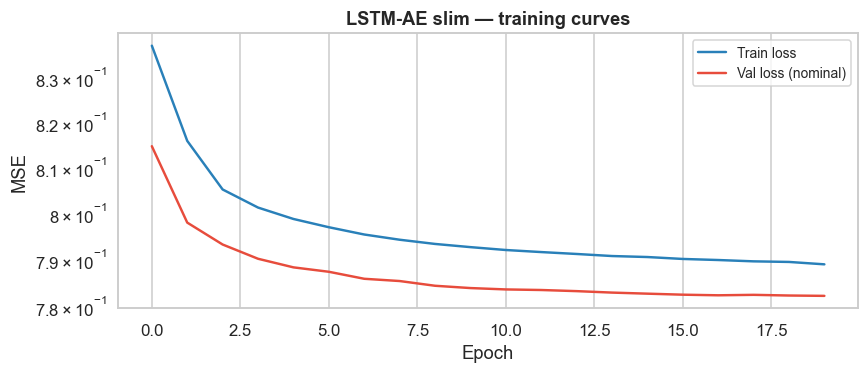

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
h = history.history
ax.plot(h['loss'],     lw=1.6, color=NOMINAL_COLOR, label='Train loss')
ax.plot(h['val_loss'], lw=1.6, color=ANOMALY_COLOR, label='Val loss (nominal)')
ax.set_yscale('log')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('LSTM-AE slim — training curves', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

## 5 — Carve val / test_internal from `train_full_scaled`

Split from the boundary-check above (anomaly-safe):

- `val           = train_full[TRAIN_END : VAL_END]` — labelled. Threshold tuning only.
- `test_internal = train_full[VAL_END : ]`        — labelled. Metrics reported here.

Both blocks live entirely **past** `TRAIN_END` (the fit cutoff) so the LSTM-AE has never seen these rows — honest out-of-sample estimate for Kaggle test.

In [8]:
X_val           = np.ascontiguousarray(train_scaled[TRAIN_END:VAL_END]).astype(np.float32)
y_val           = y_train_row[TRAIN_END:VAL_END].astype(np.int8)
X_test_internal = np.ascontiguousarray(train_scaled[VAL_END:]).astype(np.float32)
y_test_internal = y_train_row[VAL_END:].astype(np.int8)

print(f'val            : {X_val.shape}             anom={int(y_val.sum()):>7,}           [{TRAIN_END:,}:{VAL_END:,})')
print(f'test_internal  : {X_test_internal.shape}   anom={int(y_test_internal.sum()):>7,} [{VAL_END:,}:{n_full:,})')
print(f'(fit cutoff at row {TRAIN_END:,} → both blocks disjoint from fit pool)')

val            : (2000000, 58)             anom=215,798           [10,700,000:12,700,000)
test_internal  : (2028321, 58)   anom=214,935 [12,700,000:14,728,321)
(fit cutoff at row 10,700,000 → both blocks disjoint from fit pool)


## 6 — Score val + test_internal (baseline only)

`topk=5` matches NB 12: LSTM reconstruction error concentrates in a few channels; mean-over-58 dilutes the signal. No detrending — NB 12 didn't use it either, and the last-50k recency slice already aligns the nominal regime of fit / val / test.

In [9]:
# Wrap the (now z-norm-trained) model for drift-invariant scoring.
scorer = ZNormAdapter(model)

t0 = time.time()
val_scores  = score_windows(scorer, X_val,           win=WINDOW_SIZE, batch=256, topk=TOPK)
test_scores = score_windows(scorer, X_test_internal, win=WINDOW_SIZE, batch=256, topk=TOPK)
print(f'score (val + test_internal, z-norm) : {time.time()-t0:.1f}s')
print(f'  val  range  : [{val_scores.min():.4f}, {val_scores.max():.4f}]')
print(f'  test range  : [{test_scores.min():.4f}, {test_scores.max():.4f}]')
print(f'  val nominal mean  = {val_scores[y_val==0].mean():.4f}')
print(f'  val anomaly mean  = {val_scores[y_val==1].mean():.4f}')
print(f'  test nominal mean = {test_scores[y_test_internal==0].mean():.4f}')
print(f'  test anomaly mean = {test_scores[y_test_internal==1].mean():.4f}')

score (val + test_internal, z-norm) : 35.3s
  val  range  : [1.0029, 2.2206]
  test range  : [1.0033, 1.6870]
  val nominal mean  = 1.0550
  val anomaly mean  = 1.0597
  test nominal mean = 1.0551
  test anomaly mean = 1.0582


## 7 — Tune threshold on val, evaluate on test_internal

Tune against **ESA-corrected F0.5** (= event-F0.5 × TNR — Kaggle's metric) — this is the only deliberate difference vs NB 12, which tuned on raw `event_f05`. Report both event-F0.5 and ESA-F0.5 on test_internal for comparison.

In [10]:
def row_prec_rec(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    return prec, rec

tune = tune_threshold(val_scores, y_val, metric_fn=corrected_event_f05)
t_best  = float(tune['threshold'])
val_esa = float(tune['score'])
print(f'Val-tuned threshold (corrected_event_f05) : {t_best:.6f}')
print(f'Val corrected F0.5 @ best                 : {val_esa:.4f}')

y_pred_test = (test_scores > t_best).astype(np.int8)
ev  = event_f05(y_test_internal,          y_pred_test)
esa = corrected_event_f05(y_test_internal, y_pred_test)
rp, rr = row_prec_rec(y_test_internal, y_pred_test)

print('\n--- LSTM-AE (NB 12 recipe, ESA-tuned threshold) — test_internal ---')
print(f'  threshold       : {t_best:.6f}')
print(f'  event F0.5      : {ev["f_score"]:.4f}   recall {ev["recall"]:.4f}   precision {ev["precision"]:.4f}')
print(f'  ESA F0.5        : {esa["f_score"]:.4f}   TNR {esa["tnr"]:.4f}')
print(f'  row  precision  : {rp:.4f}   row recall {rr:.4f}')

Val-tuned threshold (corrected_event_f05) : 1.192511
Val corrected F0.5 @ best                 : 0.3329

--- LSTM-AE (NB 12 recipe, ESA-tuned threshold) — test_internal ---
  threshold       : 1.192511
  event F0.5      : 0.2347   recall 0.5200   precision 0.2063
  ESA F0.5        : 0.2339   TNR 0.9964
  row  precision  : 0.3342   row recall 0.0151


---
## Timeline — Val + Test

Standardized two-panel plot via `plot_timeline(scores, y_true, threshold, ..., log_y=True)`. Use `index` to switch the x-axis from split-local positions (default) to absolute dataset indices.

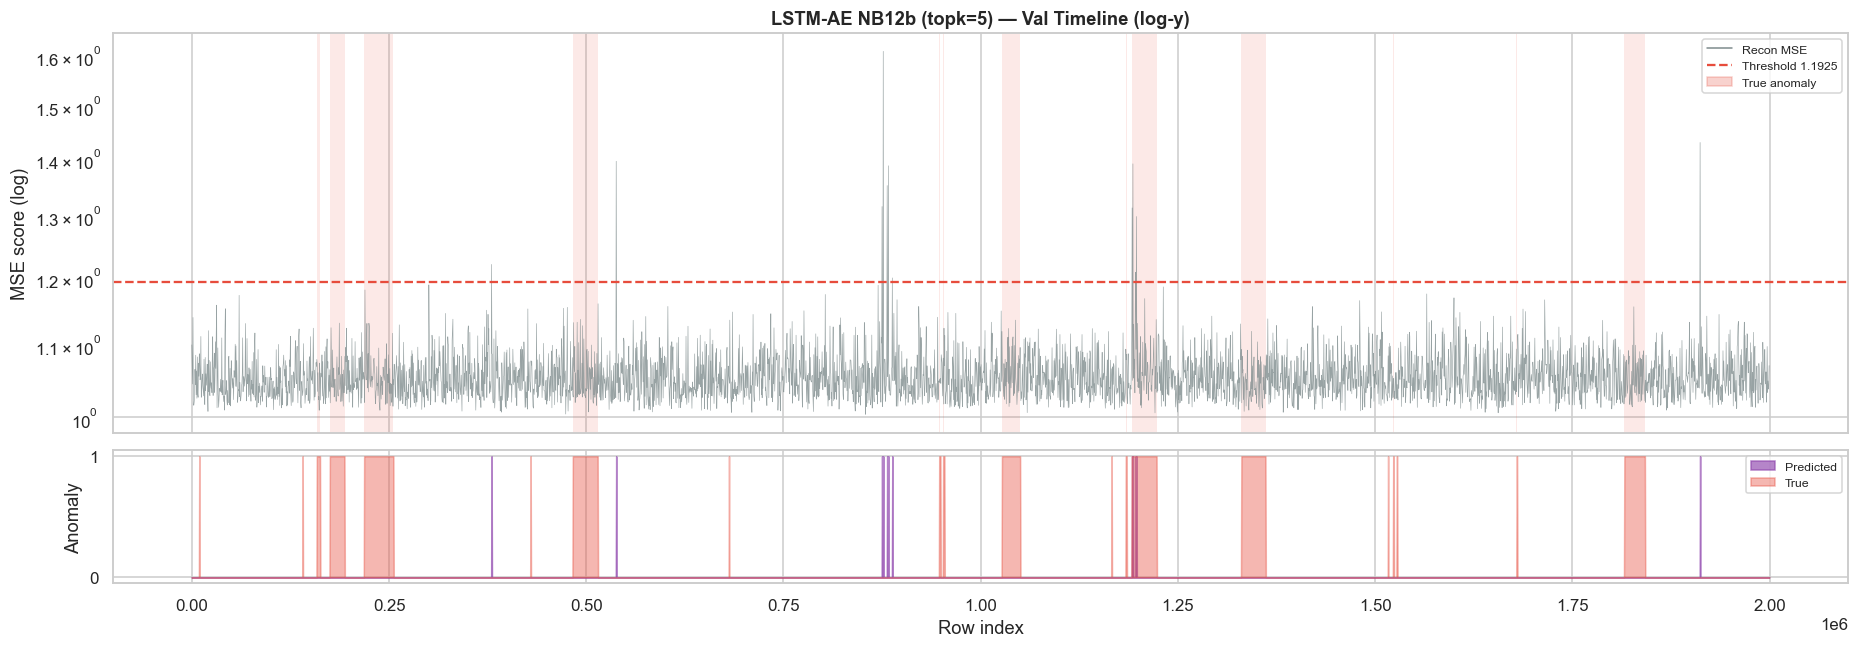

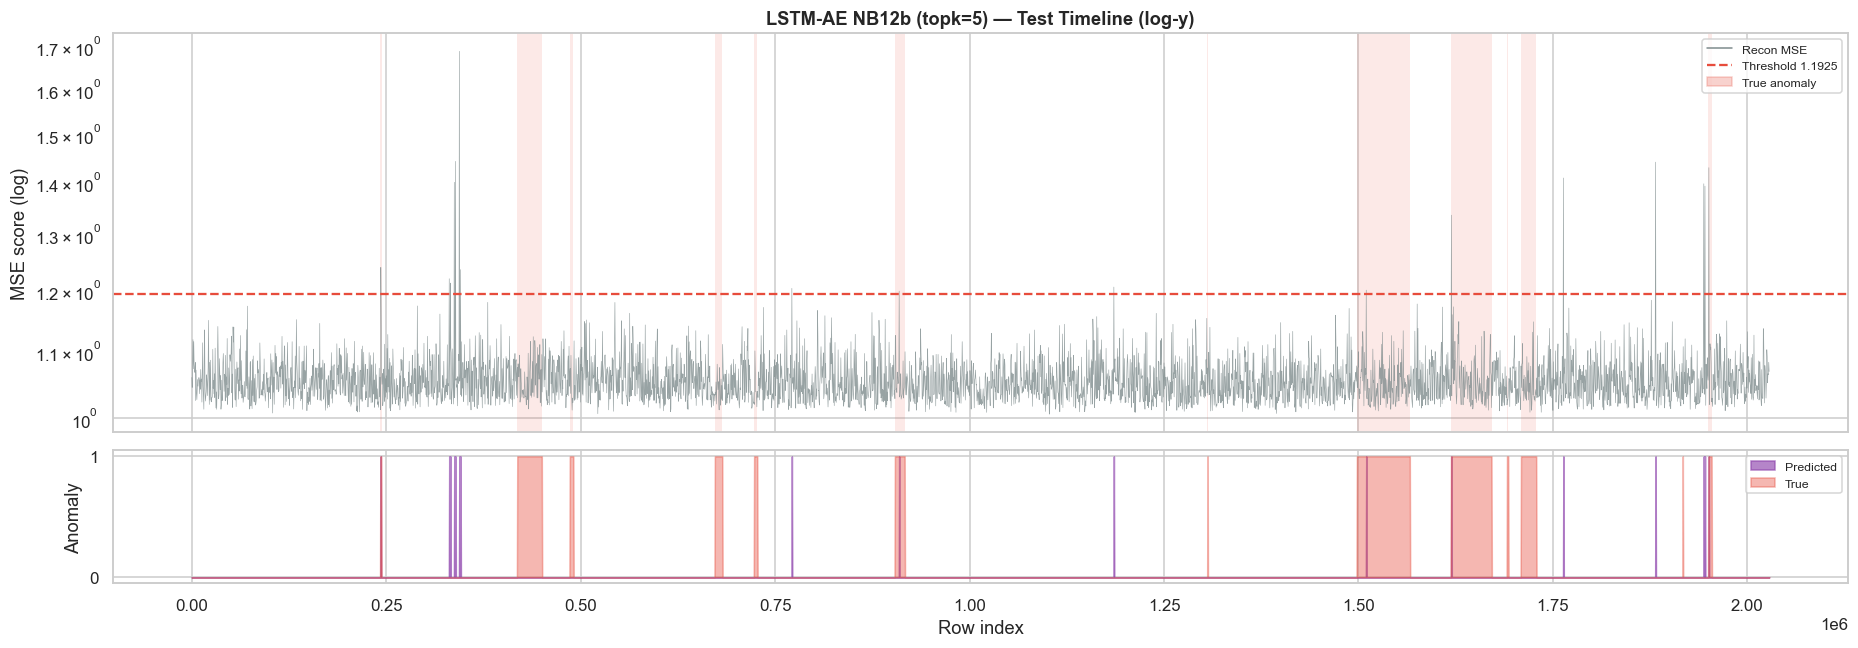

In [11]:
from sentinel.ml_logic.viz import plot_timeline

MODEL_NAME = f'LSTM-AE NB12b (topk={TOPK})'

_ = plot_timeline(val_scores, y_val, t_best,
                  f'{MODEL_NAME} — Val Timeline (log-y)', log_y=True)
plt.show(); plt.close()

_ = plot_timeline(test_scores, y_test_internal, t_best,
                  f'{MODEL_NAME} — Test Timeline (log-y)', log_y=True)
plt.show(); plt.close()

## 8b — Drift-robust threshold calibration

v3_baseline with thr=1.18 flagged **100 %** of Kaggle test — Kaggle's nominal-score floor is above val's 99.9-percentile nominal. Val-based thresholds are therefore too low regardless of percentile.

Drift-robust candidates:

- **A**: val-ESA tuned (keeps as reference — known-bad on Kaggle)
- **B–D**: percentile of **val nominal scores** — principled but may still underflag
- **E–G**: percentile of **test_internal score distribution** — test_internal sits in the drifted regime closest to Kaggle; picking a percentile that matches the expected anomaly rate (~10 %) keeps the flag rate bounded
- **H–J**: percentile of **Kaggle scores themselves** — purely unsupervised, assumes a known target flag rate

Evaluated on test_internal (for event/ESA metrics) + Kaggle flag-rate preview. Pick the winner that maximises test_internal ESA F0.5 **and** has a Kaggle flag rate ≤ 20 %.

In [12]:
# Score Kaggle via the z-norm scorer (same wrapper as val/test_internal)
X_kaggle      = test_scaled.astype(np.float32, copy=False)
kaggle_scores = score_windows(scorer, X_kaggle, win=WINDOW_SIZE, batch=256, topk=TOPK)
print(f'kaggle_scores range   : [{kaggle_scores.min():.4f}, {kaggle_scores.max():.4f}]')
print(f'test_internal range   : [{test_scores.min():.4f}, {test_scores.max():.4f}]')
print(f'val (nominal) range   : [{val_scores[y_val==0].min():.4f}, {val_scores[y_val==0].max():.4f}]')
print()

val_nom_scores = val_scores[y_val == 0]

candidates = {
    # val-ESA tuned (may still be off under drift but z-norm should shrink gap)
    'A_val_ESA_tuned'    : t_best,
    # val-nominal percentiles
    'B_val_nom_p99'      : float(np.percentile(val_nom_scores, 99.0)),
    'C_val_nom_p99_9'    : float(np.percentile(val_nom_scores, 99.9)),
    # test_internal percentiles (drift-regime matched, ~10% anomaly rate)
    'E_testint_p90'      : float(np.percentile(test_scores, 90.0)),
    'F_testint_p95'      : float(np.percentile(test_scores, 95.0)),
    'G_testint_p98'      : float(np.percentile(test_scores, 98.0)),
    # Kaggle-score percentiles (fully unsupervised anchor)
    'H_kaggle_p90'       : float(np.percentile(kaggle_scores, 90.0)),
    'I_kaggle_p95'       : float(np.percentile(kaggle_scores, 95.0)),
    'J_kaggle_p98'       : float(np.percentile(kaggle_scores, 98.0)),
}

rows = []
for name, thr in candidates.items():
    y_hat_ti = (test_scores   > thr).astype(np.int8)
    y_hat_k  = (kaggle_scores > thr).astype(np.uint8)
    ev    = event_f05(y_test_internal,          y_hat_ti)
    esa   = corrected_event_f05(y_test_internal, y_hat_ti)
    rp, rr = row_prec_rec(y_test_internal, y_hat_ti)
    rows.append({
        'candidate'     : name,
        'threshold'     : round(thr, 4),
        'event_f05'     : round(ev['f_score'],  4),
        'event_rec'     : round(ev['recall'],   4),
        'esa_f05'       : round(esa['f_score'], 4),
        'tnr'           : round(esa['tnr'],     4),
        'ti_flag_rate'  : round(float(y_hat_ti.mean()), 4),
        'kg_flag_rate'  : round(float(y_hat_k.mean()),  4),
    })
thr_df = pd.DataFrame(rows)
print('--- Threshold-candidate comparison (z-norm scoring) ---')
print('(ti_* = test_internal, kg_* = Kaggle flag-rate preview)')
print(thr_df.to_string(index=False))

safe = thr_df[thr_df['kg_flag_rate'] <= 0.20].copy()
if len(safe) == 0:
    safe = thr_df
best_idx = safe['esa_f05'].idxmax()
winner   = safe.loc[best_idx]
t_submit = float(winner['threshold'])
variant  = winner['candidate']
print(f"\nSelected for Kaggle submission: {variant}")
print(f"  threshold       = {t_submit:.6f}")
print(f"  test_internal   : event_f05={winner['event_f05']}  esa_f05={winner['esa_f05']}")
print(f"  ti_flag_rate    = {winner['ti_flag_rate']}")
print(f"  kg_flag_rate    = {winner['kg_flag_rate']}")

kaggle_scores range   : [1.0045, 1.5329]
test_internal range   : [1.0033, 1.6870]
val (nominal) range   : [1.0029, 1.9481]



--- Threshold-candidate comparison (z-norm scoring) ---
(ti_* = test_internal, kg_* = Kaggle flag-rate preview)
      candidate  threshold  event_f05  event_rec  esa_f05    tnr  ti_flag_rate  kg_flag_rate
A_val_ESA_tuned     1.1925     0.2347       0.52   0.2339 0.9964        0.0048        0.0025
  B_val_nom_p99     1.1454     0.0818       0.60   0.0808 0.9871        0.0143        0.0106
C_val_nom_p99_9     1.3149     0.3106       0.40   0.3101 0.9984        0.0022        0.0006
  E_testint_p90     1.0954     0.0154       0.76   0.0139 0.9019        0.1000        0.0998
  F_testint_p95     1.1131     0.0262       0.68   0.0249 0.9514        0.0500        0.0451
  G_testint_p98     1.1358     0.0571       0.60   0.0561 0.9813        0.0200        0.0159
   H_kaggle_p90     1.0953     0.0153       0.76   0.0138 0.9016        0.1002        0.0999
   I_kaggle_p95     1.1108     0.0237       0.68   0.0224 0.9463        0.0551        0.0499
   J_kaggle_p98     1.1302     0.0477       0.64   

---
## Submission & Save model

Nach dem Review der Ergebnisse oben die gewünschten Blöcke auskommentieren und ausführen.

In [13]:
# ── Save model ──────────────────────────────────────────────────────────
# import time
# MODELS_DIR.mkdir(exist_ok=True)
# ts = time.strftime('%Y%m%d_%H%M%S')
# model_path = MODELS_DIR / f'lstm_ae_nb12b_{ts}.keras'
# model.save(model_path)
# print(f'Model saved → {model_path}')


In [14]:
# Save scores — nach Review auskommentieren und ausführen
# SCORES_DIR = PROCESSED_DIR / 'scores'
# SCORES_DIR.mkdir(parents=True, exist_ok=True)
# np.save(SCORES_DIR / 'scores_val_lstm_ae_nb12b.npy',  val_scores)
# np.save(SCORES_DIR / 'scores_test_lstm_ae_nb12b.npy', test_scores)
# print(f'Scores saved → {SCORES_DIR}/scores_{{val,test}}_lstm_ae_nb12b.npy')


In [15]:
# ── Kaggle submission ───────────────────────────────────────────────────
# # kaggle_scores already computed in the calibration cell above
# print(f'Submitting with variant={variant}  threshold={t_submit:.6f}')
# y_kaggle = (kaggle_scores > t_submit).astype(np.uint8)
# print(f'  positive rate : {y_kaggle.mean():.4%}  ({int(y_kaggle.sum()):,} / {len(y_kaggle):,})')
#
# import time as _t
# ts = _t.strftime('%Y%m%d_%H%M%S')
# stem = f'lstm_ae_nb12b_{variant}_{ts}'
# out_path = default_submission_path(stem)
# submission = make_submission(
#     predictions     = y_kaggle,
#     test_ids        = test_ids,
#     out_path        = out_path,
#     validate_schema = True,
# )
# print(f'\nSubmission written: {out_path}')
# print(submission_summary(submission))
